<a href="https://colab.research.google.com/github/AllyApitchaya/msc-adr-prediction/blob/main/notebooks/09_make_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/ADR_Project'
os.makedirs(os.path.join(PROJECT, 'results/figs_data'), exist_ok=True)

print('PROJECT ok:', os.path.isdir(PROJECT))
print(os.listdir(os.path.join(PROJECT, 'results'))[:5])

Mounted at /content/drive
PROJECT ok: True
['disproportionality_results.csv', 'baseline_xgboost_metrics.csv', 'gnn_test_metrics.csv', 'multimodal_test_metrics.csv', 'ablation_results.csv']


In [5]:
import pandas as pd, numpy as np, os

test_df = pd.read_csv(os.path.join(PROJECT, 'data/processed/test.csv'))
dis     = pd.read_csv(os.path.join(PROJECT, 'results/disproportionality_results.csv'))

print('dis rows :', len(dis), '| dis drugs:', dis.drug.nunique())
print('test rows:', len(test_df))

def key(df):
    return (df.drug.astype(str).str.lower().str.strip() + '||' +
            df.adr.astype(str).str.lower().str.strip())

t = test_df.copy(); t['k'] = key(t)
d = dis.copy();     d['k'] = key(d)

m = t.merge(d[['k', 'a', 'prr']].drop_duplicates('k'), on='k', how='left')

m['in_dis']     = m.a.notna()
m['scoreable']  = m.a.fillna(0) >= 3
m['prr_signal'] = (m.prr.fillna(0) >= 2.0) & m.scoreable

print()
print('test pairs found in dis table   :', int(m.in_dis.sum()),
      f'({m.in_dis.mean():.1%})')
print('PRR signals inside test set     :', int(m.prr_signal.sum()))
print('NOT scoreable by PRR (a<3 or absent):', int((~m.scoreable).sum()),
      f'= {(~m.scoreable).mean():.1%}   <-- ตัวเลขสำหรับ Table 5.4')

m.to_csv(os.path.join(PROJECT, 'results/figs_data/test_prr_join.csv'), index=False)

dis rows : 5101 | dis drugs: 15
test rows: 9016

test pairs found in dis table   : 2599 (28.8%)
PRR signals inside test set     : 533
NOT scoreable by PRR (a<3 or absent): 7537 = 83.6%   <-- ตัวเลขสำหรับ Table 5.4


In [7]:
import numpy as np, pandas as pd, os

m = pd.read_csv(os.path.join(PROJECT, 'results/figs_data/test_prr_join.csv'))
z = np.load(os.path.join(PROJECT, 'results/figs_data/crossattn_preds.npz'),
            allow_pickle=True)

pred = pd.DataFrame({'drug': z['drug'], 'adr': z['reaction'],
                     'label': z['y_true'], 'score': z['crossattn']})
pred['k'] = (pred.drug.astype(str).str.lower().str.strip() + '||' +
             pred.adr.astype(str).str.lower().str.strip())

mm = m.merge(pred[['k', 'score']].drop_duplicates('k'), on='k', how='left')
print('rows with score:', int(mm.score.notna().sum()), '/', len(mm))

mm['model_pos'] = mm.score >= 0.5

n_sig      = int(mm.prr_signal.sum())
confirmed  = int((mm.prr_signal & mm.model_pos).sum())
missed     = n_sig - confirmed
novel      = int((~mm.prr_signal & mm.model_pos).sum())
unscorable = int((~mm.scoreable).sum())

print()
print(f'PRR signals in test set        : {n_sig}')
print(f'  confirmed by model           : {confirmed}  ({confirmed/n_sig:.1%})')
print(f'  missed by model              : {missed}')
print(f'novel model positives (no PRR) : {novel}')
print(f'below PRR threshold            : {unscorable}  ({unscorable/len(mm):.1%})')
print(f'total model positives          : {int(mm.model_pos.sum())}')

rows with score: 9016 / 9016

PRR signals in test set        : 533
  confirmed by model           : 512  (96.1%)
  missed by model              : 21
novel model positives (no PRR) : 3574
below PRR threshold            : 7537  (83.6%)
total model positives          : 4086


In [8]:
test_df = pd.read_csv(os.path.join(PROJECT, 'data/processed/test.csv'))
print(test_df.columns.tolist())
print(test_df.head(3).to_string())
print('\ndrugs:', test_df.drug.nunique())

['drug', 'pubchem_cid', 'smiles', 'adr', 'label']
            drug  pubchem_cid                                                   smiles                adr  label
0      metformin         4091                                        CN(C)C(=N)N=C(N)N   Skin haemorrhage      1
1  dapagliflozin      9887712  CCOC1=CC=C(C=C1)CC2=C(C=CC(=C2)C3C(C(C(C(O3)CO)O)O)O)Cl  Dermatitis diaper      1
2  dapagliflozin      9887712  CCOC1=CC=C(C=C1)CC2=C(C=CC(=C2)C3C(C(C(C(O3)CO)O)O)O)Cl    Nephrolithiasis      1

drugs: 14


In [9]:
import numpy as np, pandas as pd, os
from sklearn.metrics import roc_auc_score, average_precision_score

z = np.load(os.path.join(PROJECT, 'results/figs_data/crossattn_preds.npz'),
            allow_pickle=True)
df = pd.DataFrame({'drug': z['drug'], 'adr': z['reaction'],
                   'y': z['y_true'].astype(int), 'p': z['crossattn']})

train_df = pd.read_csv(os.path.join(PROJECT, 'data/processed/train.csv'))
print('train drugs:', sorted(train_df.drug.unique()))
print('test  drugs:', sorted(df.drug.unique()))
print('MISSING from test:', sorted(set(train_df.drug) - set(df.drug)))
print('MISSING from train:', sorted(set(df.drug) - set(train_df.drug)))

CLASS = {
    'metformin':'Biguanides',
    'glipizide':'Sulphonylureas','glyburide':'Sulphonylureas','glimepiride':'Sulphonylureas',
    'pioglitazone':'Thiazolidinediones','rosiglitazone':'Thiazolidinediones',
    'sitagliptin':'DPP-4 inhibitors','saxagliptin':'DPP-4 inhibitors','linagliptin':'DPP-4 inhibitors',
    'empagliflozin':'SGLT2 inhibitors','canagliflozin':'SGLT2 inhibitors','dapagliflozin':'SGLT2 inhibitors',
    'repaglinide':'Meglitinides','nateglinide':'Meglitinides',
    'acarbose':'Alpha-glucosidase inhibitors',
}
df['cls'] = df.drug.str.lower().map(CLASS)
print('\nunmapped drugs:', df[df.cls.isna()].drug.unique())

print('\n===== Table 5.5: per-class AUROC =====')
for c, g in df.groupby('cls'):
    if g.y.nunique() < 2:
        print(f'{c:32s} n={len(g):5d}  (single class - skip)'); continue
    print(f'{c:32s} n={len(g):5d}  pos={g.y.mean():.2f}  '
          f'AUROC={roc_auc_score(g.y, g.p):.3f}  '
          f'drugs={sorted(g.drug.unique())}')

print('\n===== Table 4.3: operating points =====')
for t in [0.7, 0.5, 0.3]:
    pr = df.p >= t
    print(f'threshold {t}: precision={pr[df.y==1].sum()/pr.sum():.3f}  '
          f'sensitivity={pr[df.y==1].sum()/(df.y==1).sum():.3f}')

train drugs: ['acarbose', 'canagliflozin', 'dapagliflozin', 'empagliflozin', 'glimepiride', 'glipizide', 'glyburide', 'linagliptin', 'metformin', 'nateglinide', 'pioglitazone', 'repaglinide', 'rosiglitazone', 'saxagliptin', 'sitagliptin']
test  drugs: ['acarbose', 'canagliflozin', 'dapagliflozin', 'empagliflozin', 'glimepiride', 'glipizide', 'glyburide', 'linagliptin', 'metformin', 'nateglinide', 'pioglitazone', 'repaglinide', 'saxagliptin', 'sitagliptin']
MISSING from test: ['rosiglitazone']
MISSING from train: []

unmapped drugs: []

===== Table 5.5: per-class AUROC =====
Alpha-glucosidase inhibitors     n=  377  pos=0.03  AUROC=0.894  drugs=['acarbose']
Biguanides                       n= 2052  pos=0.92  AUROC=0.617  drugs=['metformin']
DPP-4 inhibitors                 n= 1551  pos=0.35  AUROC=0.629  drugs=['linagliptin', 'saxagliptin', 'sitagliptin']
Meglitinides                     n=  757  pos=0.06  AUROC=0.898  drugs=['nateglinide', 'repaglinide']
SGLT2 inhibitors               

In [10]:
from scipy.stats import spearmanr
s = df.groupby('cls').agg(pos=('y','mean'), auroc=('y', lambda x: 0)).reset_index()
rows = [(c, g.y.mean(), roc_auc_score(g.y, g.p)) for c, g in df.groupby('cls')]
r = pd.DataFrame(rows, columns=['cls','pos','auroc'])
print(r.sort_values('pos').to_string(index=False))
print('\nSpearman rho (pos rate vs AUROC):', spearmanr(r.pos, r.auroc))

                         cls      pos    auroc
Alpha-glucosidase inhibitors 0.031830 0.893607
                Meglitinides 0.063408 0.898125
              Sulphonylureas 0.257969 0.849846
          Thiazolidinediones 0.275269 0.785701
            DPP-4 inhibitors 0.345583 0.629402
            SGLT2 inhibitors 0.627586 0.739832
                  Biguanides 0.920565 0.616839

Spearman rho (pos rate vs AUROC): SignificanceResult(statistic=np.float64(-0.9285714285714288), pvalue=np.float64(0.0025194724037946874))


In [11]:
r.to_csv(os.path.join(PROJECT, 'results/figs_data/per_class_auroc.csv'), index=False)

ops = pd.DataFrame([
    {'threshold': t,
     'precision': (df.p >= t)[df.y == 1].sum() / (df.p >= t).sum(),
     'sensitivity': (df.p >= t)[df.y == 1].sum() / (df.y == 1).sum()}
    for t in [0.7, 0.5, 0.3]])
ops.to_csv(os.path.join(PROJECT, 'results/figs_data/operating_points.csv'), index=False)

pd.DataFrame([{'prr_signals': 533, 'confirmed': 512, 'missed': 21,
               'novel': 3574, 'below_threshold': 7537,
               'below_threshold_pct': 0.836,
               'spearman_rho': -0.9286, 'spearman_p': 0.00252}]
).to_csv(os.path.join(PROJECT, 'results/figs_data/table54_summary.csv'), index=False)

print(os.listdir(os.path.join(PROJECT, 'results/figs_data')))

['crossattn_preds.npz', 'test_prr_join.csv', 'per_class_auroc.csv', 'operating_points.csv', 'table54_summary.csv']


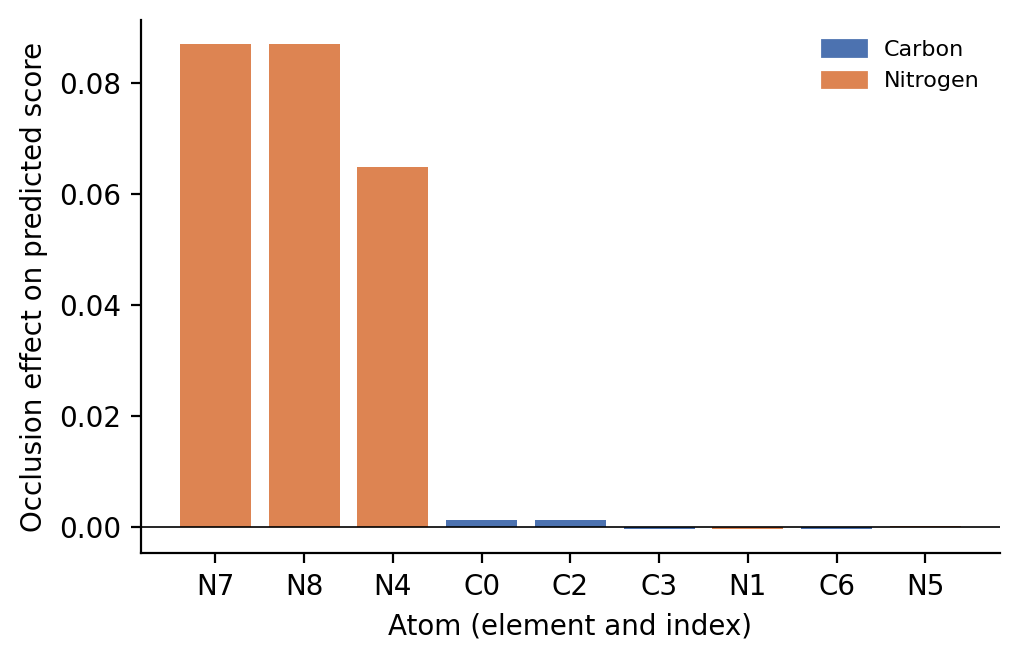

 atom_idx element    effect
        7       N  0.087029
        8       N  0.087029
        4       N  0.064838
        0       C  0.001135
        2       C  0.001135
        3       C -0.000449
        1       N -0.000446
        6       C -0.000354
        5       N  0.000131


In [12]:
import pandas as pd, matplotlib.pyplot as plt, os
from matplotlib.patches import Patch

OUT = os.path.join(PROJECT, 'results/figs_data')
att = pd.read_csv(os.path.join(PROJECT, 'results/atom_attribution_metformin.csv'))

# เรียงตามขนาดของค่า (มาก -> น้อย) ให้ตรงกับลำดับใน Table 5.1
att = att.reindex(att.effect.abs().sort_values(ascending=False).index)

labels = att.element + att.atom_idx.astype(str)
colors = ['#4C72B0' if e == 'C' else '#DD8452' for e in att.element]

fig, ax = plt.subplots(figsize=(5.2, 3.4), dpi=200)
ax.bar(labels, att.effect, color=colors)
ax.axhline(0, c='k', lw=0.6)
ax.set_xlabel('Atom (element and index)')
ax.set_ylabel('Occlusion effect on predicted score')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[Patch(color='#4C72B0', label='Carbon'),
                   Patch(color='#DD8452', label='Nitrogen')],
          frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(OUT, 'fig_atom_attribution.pdf'))
plt.show()

print(att.to_string(index=False))

In [13]:
from google.colab import files
files.download(os.path.join(OUT, 'fig_atom_attribution.pdf'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import pandas as pd, os
for name in ['train', 'val', 'test']:
    d = pd.read_csv(os.path.join(PROJECT, f'data/processed/{name}.csv'))
    print(f'{name:6s} rows={len(d):6d}  '
          f'unique pairs={d[["drug","adr"]].drop_duplicates().shape[0]:6d}  '
          f'positives={int((d.label==1).sum()):6d}  '
          f'drugs={d.drug.nunique()}  adrs={d.adr.nunique()}')

train  rows=  8240  unique pairs=  8240  positives=  4120  drugs=15  adrs=3272
val    rows=  4912  unique pairs=  4912  positives=  2456  drugs=14  adrs=2664
test   rows=  9016  unique pairs=  9016  positives=  4508  drugs=14  adrs=3330
